In [1]:
import pandas as pd
import numpy as np

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
#    1   2   3   4   5   6  user_id

# 1  4.0

# 2  NaN

# 3  4.5

# 4  NaN

# movies_id

final_dataset = ratings.pivot(index="movieId", columns="userId", values="rating")

In [6]:
final_dataset

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
final_dataset.fillna(0, inplace=True)

In [8]:
final_dataset

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
193583,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
193585,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Removing noisy data from dataset

In [10]:
#Seasonal movie fan -> salar, let i watch 15 movies in 1 year, and gave 5 rating
#let i watch 150 movies in 1 year, and gave rating 100
#so both are similer me watching 15 or my frnd watching 150

# we checking which movies are qualifying
#so
# atleast 50 user should vote for movie ratings

no_user_voted = ratings.groupby("movieId")['rating'].agg('count')
no_movies_voted = ratings.groupby("userId")['rating'].agg('count')

In [11]:
no_user_voted

movieId
1         215
2         110
3          52
4           7
5          49
         ... 
193581      1
193583      1
193585      1
193587      1
193609      1
Name: rating, Length: 9724, dtype: int64

In [12]:
no_movies_voted

userId
1       232
2        29
3        39
4       216
5        44
       ... 
606    1115
607     187
608     831
609      37
610    1302
Name: rating, Length: 610, dtype: int64

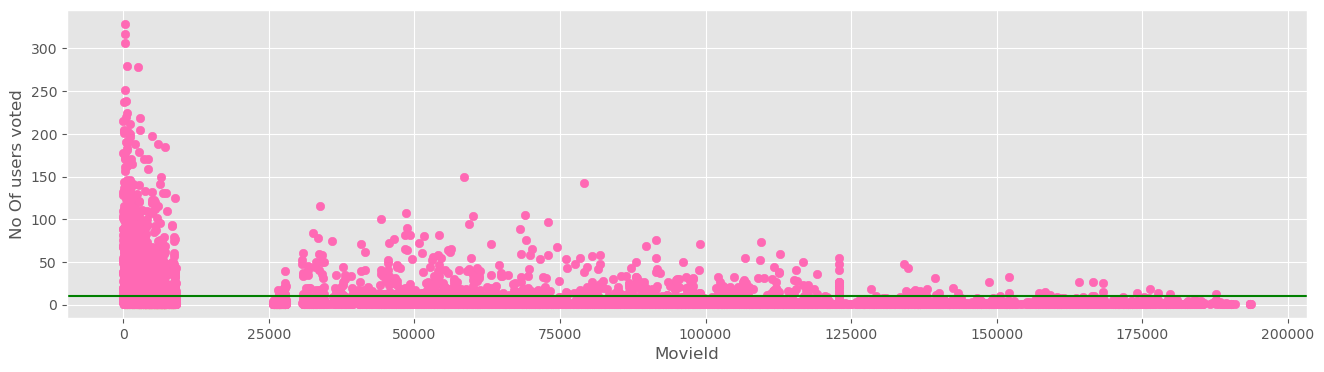

In [13]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
fig,axes = plt.subplots(1,1, figsize=(16,4))
plt.scatter(no_user_voted.index, no_user_voted, color="hotpink")
plt.axhline(y=10, color='green')
plt.xlabel("MovieId")
plt.ylabel("No Of users voted")
plt.show()

In [14]:
#so those who lies under that line will remove because they do not gave proper ratings, they rate under 10

final_dataset = final_dataset.loc[no_user_voted[no_user_voted  > 10].index, :]

In [15]:
final_dataset

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
6,4.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,3.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
176371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


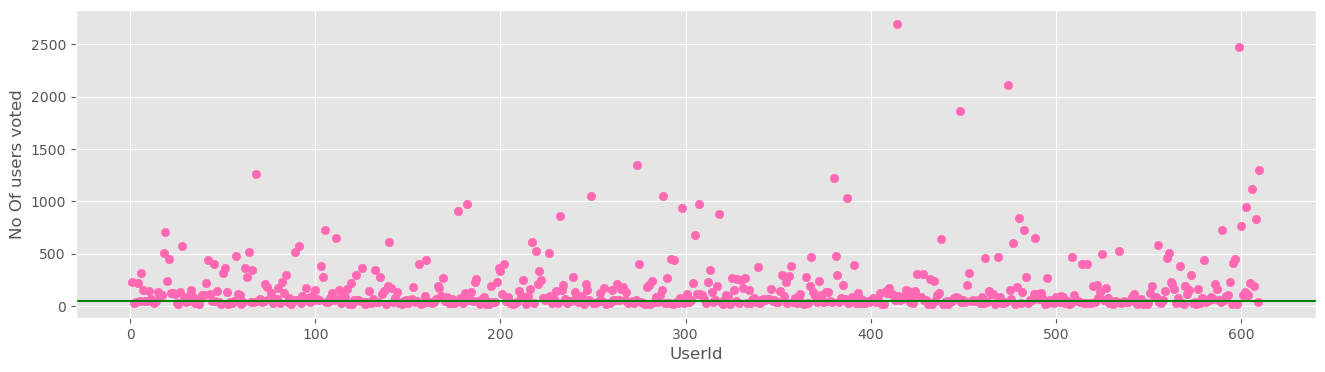

In [16]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
fig,axes = plt.subplots(1,1, figsize=(16,4))
plt.scatter(no_movies_voted.index, no_movies_voted, color="hotpink")
plt.axhline(y=50, color='green')
plt.xlabel("UserId")
plt.ylabel("No Of users voted")
plt.show()

In [18]:
#so those who lies under that line will remove because those movies did not receive ratings more then 50


final_dataset = final_dataset.loc[: , no_movies_voted[no_movies_voted  > 50 ].index]

In [19]:
final_dataset

userId,1,4,6,7,10,11,15,16,17,18,...,600,601,602,603,604,605,606,607,608,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,4.5,0.0,0.0,2.5,0.0,4.5,3.5,...,2.5,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,5.0
2,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,4.0,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0
3,4.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
5,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.5,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
6,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0,0.0,4.0,...,0.0,0.0,3.0,4.0,3.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
176371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# remove spersity from dataset

2121 * 378

801738

In [22]:
# exmple that what is mean of sparcity:
#most of the no are 0.0 in our dataset thats we called sparcity or sparce matrix


sample = np.array([[1,0,0,0,0], [0,0,2,0,0], [0,0,4,0,0]])
#no of non zeros are divided by sameple size 
sparsity = 1.0 - (np.count_nonzero(sample) / float(sample.size))
print(sparsity)

0.8


In [23]:
from scipy.sparse import csr_matrix
csr_sample = csr_matrix(sample)
print(csr_sample)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (3, 5)>
  Coords	Values
  (0, 0)	1
  (1, 2)	2
  (2, 2)	4


In [25]:
#use this in our dataset

csr_data = csr_matrix(final_dataset.values)
final_dataset.reset_index(inplace=True)
print(csr_data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 72893 stored elements and shape (2121, 378)>
  Coords	Values
  (0, 0)	4.0
  (0, 3)	4.5
  (0, 6)	2.5
  (0, 8)	4.5
  (0, 9)	3.5
  (0, 10)	4.0
  (0, 12)	3.5
  (0, 16)	3.0
  (0, 19)	3.0
  (0, 20)	3.0
  (0, 25)	5.0
  (0, 28)	5.0
  (0, 29)	4.0
  (0, 31)	3.0
  (0, 34)	5.0
  (0, 38)	5.0
  (0, 39)	4.0
  (0, 40)	4.0
  (0, 41)	2.5
  (0, 43)	4.5
  (0, 46)	0.5
  (0, 47)	4.0
  (0, 50)	2.5
  (0, 53)	4.0
  (0, 55)	3.0
  :	:
  (2118, 205)	4.0
  (2118, 345)	1.5
  (2118, 357)	4.0
  (2118, 369)	4.5
  (2119, 37)	3.5
  (2119, 62)	3.0
  (2119, 98)	0.5
  (2119, 127)	4.5
  (2119, 156)	4.5
  (2119, 236)	0.5
  (2119, 256)	4.5
  (2119, 317)	2.0
  (2119, 345)	2.0
  (2119, 357)	5.0
  (2119, 365)	3.5
  (2120, 37)	4.0
  (2120, 62)	5.0
  (2120, 146)	2.5
  (2120, 155)	4.5
  (2120, 156)	5.0
  (2120, 186)	5.0
  (2120, 205)	4.0
  (2120, 236)	3.0
  (2120, 317)	3.5
  (2120, 357)	4.0


In [ ]:
#we removd all zeros from our dataset 

In [27]:
#now we use KNN (K-Nearest neighbor)

from sklearn.neighbors import NearestNeighbors
knn = NearestNeighbors(metric='cosine', algorithm = 'brute', n_neighbors = 20, n_jobs = -1)
knn.fit(csr_data)


#brute for algo means simple way to use : exple is like 4 no password if you forgot, so according to brute force you just start it from the 0001. 0002, 0003.....

,n_neighbors,20
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,-1


In [29]:
#now we define a fuction called get recommendation and take one movie name and based on the movie name we going to recommend the movies userrs.

def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    print(movie_list)

In [30]:
# Now if we call that function with passing movie title it gave uss a recommendations

get_recommendation("Toy Story")

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
2355       Adventure|Animation|Children|Comedy|Fantasy  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  


In [31]:
# If we gave a wrong title, it shows not in the dataset 

get_recommendation(" XYZ XYZ")

Empty DataFrame
Columns: [movieId, title, genres]
Index: []


In [32]:
# if movie inside the length of dataset this print movie fiund and if not the write movie not found

def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    if len(movie_list):
        print("Movies Found")
    else:
        print("Movies Not Found..")

In [33]:
get_recommendation("dddddsjfnjksdjgjs")

Movies Not Found..


In [38]:
get_recommendation("Toy")

Movies Found


In [37]:
# In knn it will give us a no not the text
#so we use movieId index no not the title name 

In [41]:
def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    print(movie_list)
    if len(movie_list):
        movie_list.iloc[0]['movieId'] 
    else:
        print("Movies Not Found..")

In [40]:
get_recommendation("Toy")

      movieId                    title  \
0           1         Toy Story (1995)   
1492     2017  Babes in Toyland (1961)   
1674     2253              Toys (1992)   
2329     3086  Babes in Toyland (1934)   
2355     3114       Toy Story 2 (1999)   
3595     4929          Toy, The (1982)   
4089     5843      Toy Soldiers (1991)   
7355    78499       Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
1492                          Children|Fantasy|Musical  
1674                                    Comedy|Fantasy  
2329                   Children|Comedy|Fantasy|Musical  
2355       Adventure|Animation|Children|Comedy|Fantasy  
3595                                            Comedy  
4089                                      Action|Drama  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  


In [43]:
def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        print(movie_idx)

    else:
        print("Movies Not Found..")

In [44]:
get_recommendation("Toy Story")

1


In [48]:
# what we do hear we searching these movie index in our final dataset, form till now we search from our movies list data only 

def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        print(movie_idx)

    else:
        print("Movies Not Found..")

In [49]:
get_recommendation("Toy Story")

0


In [50]:
get_recommendation("Jumanji")

1


In [51]:
get_recommendation("Wating to Exhale")

Movies Not Found..


In [52]:
# So this Waiting to Exhale movie is not in the final dataset 

In [53]:
get_recommendation("Wating to Exhale (19995)")

Movies Not Found..


C:\Users\Dhirendra Yadav\AppData\Local\Temp\ipykernel_18148\3211551201.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_list = movies[movies['title'].str.contains(movie_name)]


In [54]:
# So in final this movie is not in our final dataset but it is in the movie list 
#when  we move out and filter some low rating and low user active via graph this movie was also removed

In [55]:
# what we do hear we searching these movie index in our final dataset, form till now we search from our movies list data only 

def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    print(movie_list)
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        print(movie_idx)

    else:
        print("Movies Not Found..")

In [56]:
get_recommendation("Toy Story")

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
2355       Adventure|Animation|Children|Comedy|Fantasy  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  
0


In [57]:
# now we fit our csr (sparse) data to with our model 
#knn is model(supervised machine learning algorithm used for both classification and regression tasks)


def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    print(movie_list)
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        print(movie_idx)
        distance, indices = knn.kneighbors(csr_data[movie_idx], n_neighbors=10+1) 
        print(distance)
    else:
        print("Movies Not Found..")

# 10+1 means it will recommend 11 movies accept that one we search 


In [58]:
get_recommendation("Toy Story")

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
2355       Adventure|Animation|Children|Comedy|Fantasy  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  
0
[[0.         0.33488418 0.35654155 0.37163656 0.3807886  0.38147203
  0.38463266 0.39066272 0.39829308 0.39857809 0.39949482]]


In [59]:
# distanc ematrix from each of the column, each of the movie name 

In [60]:
# now we fit our csr (sparse) data to with our model 
#knn is model(supervised machine learning algorithm used for both classification and regression tasks)


def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    print(movie_list)
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        print(movie_idx)
        distance, indices = knn.kneighbors(csr_data[movie_idx], n_neighbors=10+1) 
        print(indices)
    else:
        print("Movies Not Found..")

# 10+1 means it will recommend 11 movies accept that one we search 


In [61]:
get_recommendation("Toy Story")

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
2355       Adventure|Animation|Children|Comedy|Fantasy  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  
0
[[   0  217  169 1048  124 1292   67  454  141  173  500]]


In [63]:
# these above are the index no of the movie 
#based on the index no we found the movie name 

In [64]:
#now combine the index and distance both

def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    print(movie_list)
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        print(movie_idx)
        distance, indices = knn.kneighbors(csr_data[movie_idx], n_neighbors=10+1) 
        rec_movies_indices = sorted(list(zip(indices.squeeze().tolist(), distance.squeeze().tolist())), key=lambda x: x[1])[:0: -1]
        print(rec_movies_indices)
        recommended_movies = []
        for val in rec_movies_indices:
            movie_idx = final_dataset.iloc[val[0]]['movieId']
            idx = movies[movies['movieId'] ==movie_idx].index
            recommended_movies.append({'Title': movies.iloc[idx]['title'].values[0], 'Distance': val[1]})
        df = pd.DataFrame(recommended_movies, index=range(1, 11))
        print(df)
    else:
        print("Movies Not Found..")

#in this we make distance in sorted mannaer like decending order so which one is more corelated or more similar


In [65]:
get_recommendation("Toy Story")

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
2355       Adventure|Animation|Children|Comedy|Fantasy  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  
0
[(500, 0.39949482401724834), (173, 0.3985780912457598), (141, 0.3982930777974919), (454, 0.39066271577950284), (67, 0.38463266223098214), (1292, 0.3814720344599547), (124, 0.3807886031957386), (1048, 0.37163656407393986), (169, 0.3565415477121445), (217, 0.33488418488394356)]


In [66]:
#now combine the index and distance both

def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    print(movie_list)
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        print(movie_idx)
        distance, indices = knn.kneighbors(csr_data[movie_idx], n_neighbors=10+1) 
        rec_movies_indices = sorted(list(zip(indices.squeeze().tolist(), distance.squeeze().tolist())), key=lambda x: x[1])[:0: -1]
        print(rec_movies_indices)
        recommended_movies = []
        for val in rec_movies_indices:
            movie_idx = final_dataset.iloc[val[0]]['movieId']
            idx = movies[movies['movieId'] ==movie_idx].index
            recommended_movies.append({'Title': movies.iloc[idx]['title'].values[0], 'Distance': val[1]})
        df = pd.DataFrame(recommended_movies, index=range(1, 11))
        print(df)
    else:
        print("Movies Not Found..")

#in this we make distance in sorted mannaer like decending order so which one is more corelated or more similar


In [67]:
get_recommendation("Toy Story")

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
2355       Adventure|Animation|Children|Comedy|Fantasy  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  
0
[(500, 0.39949482401724834), (173, 0.3985780912457598), (141, 0.3982930777974919), (454, 0.39066271577950284), (67, 0.38463266223098214), (1292, 0.3814720344599547), (124, 0.3807886031957386), (1048, 0.37163656407393986), (169, 0.3565415477121445), (217, 0.33488418488394356)]
                                                Title  Distance
1                                Groundhog Day (1993)  0.399495
2                               Lion King, The (1994)  0.398578
3                                 Pulp Fiction (1994)  0.398293
4   Star Wars: Episode VI - Return of the Jedi (1983)  0.390663
5                       

In [68]:
#now combine the index and distance both

def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    print(movie_list)
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        distance, indices = knn.kneighbors(csr_data[movie_idx], n_neighbors=10+1) 
        rec_movies_indices = sorted(list(zip(indices.squeeze().tolist(), distance.squeeze().tolist())), key=lambda x: x[1])[:0: -1]
        recommended_movies = []
        for val in rec_movies_indices:
            movie_idx = final_dataset.iloc[val[0]]['movieId']
            idx = movies[movies['movieId'] ==movie_idx].index
            recommended_movies.append({'Title': movies.iloc[idx]['title'].values[0], 'Distance': val[1]})
        df = pd.DataFrame(recommended_movies, index=range(1, 11))
        return df
    else:
        return"Movies Not Found.."

#in this we make distance in sorted mannaer like decending order so which one is more corelated or more similar


In [69]:
get_recommendation("Toy Story")

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
2355       Adventure|Animation|Children|Comedy|Fantasy  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  


,Title,Distance
1,Groundhog Day (1993),0.399495
2,"Lion King, The (1994)",0.398578
3,Pulp Fiction (1994),0.398293
4,Star Wars: Episode VI - Return of the Jedi (1983),0.390663
5,Apollo 13 (1995),0.384633
6,Shrek (2001),0.381472
7,Star Wars: Episode IV - A New Hope (1977),0.380789
8,Toy Story 2 (1999),0.371637
9,Forrest Gump (1994),0.356542
10,Jurassic Park (1993),0.334884


In [70]:
get_recommendation("Iron Man")

      movieId                                  title  \
6743    59315                        Iron Man (2008)   
7324    77561                      Iron Man 2 (2010)   
8142   102007        Invincible Iron Man, The (2007)   
8151   102125                      Iron Man 3 (2013)   
9058   142056  Iron Man & Hulk: Heroes United (2013)   
9444   167296                        Iron Man (1931)   

                                     genres  
6743                Action|Adventure|Sci-Fi  
7324  Action|Adventure|Sci-Fi|Thriller|IMAX  
8142                              Animation  
8151            Action|Sci-Fi|Thriller|IMAX  
9058             Action|Adventure|Animation  
9444                                  Drama  


,Title,Distance
1,Up (2009),0.368857
2,Guardians of the Galaxy (2014),0.368758
3,Watchmen (2009),0.368558
4,Star Trek (2009),0.366029
5,Batman Begins (2005),0.362759
6,Avatar (2009),0.310893
7,Iron Man 2 (2010),0.307492
8,WALL·E (2008),0.298138
9,"Dark Knight, The (2008)",0.285835
10,"Avengers, The (2012)",0.285319


In [71]:
get_recommendation("Iron Man112333")

Empty DataFrame
Columns: [movieId, title, genres]
Index: []


'Movies Not Found..'

In [77]:
import gradio as gr

def recommend_movies(movie_name):
    return get_recommendation(movie_name)

app = gr.Interface(
    fn=recommend_movies,
    inputs=gr.Textbox(label="MOVIE NAME"),
    outputs=gr.Dataframe(label="RECOMMENDED MOVIES"),
    title="Movie Recommendation System",
    description="Enter a movie name to get recommendations"
)

app.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


      movieId                                  title  \
6743    59315                        Iron Man (2008)   
7324    77561                      Iron Man 2 (2010)   
8142   102007        Invincible Iron Man, The (2007)   
8151   102125                      Iron Man 3 (2013)   
9058   142056  Iron Man & Hulk: Heroes United (2013)   
9444   167296                        Iron Man (1931)   

                                     genres  
6743                Action|Adventure|Sci-Fi  
7324  Action|Adventure|Sci-Fi|Thriller|IMAX  
8142                              Animation  
8151            Action|Sci-Fi|Thriller|IMAX  
9058             Action|Adventure|Animation  
9444                                  Drama  
      movieId                                              title  \
75         83    Once Upon a Time... When We Were Colored (1995)   
115       140                       Up Close and Personal (1996)   
358       414                           Air Up There, The (1994)   
406       468

Traceback (most recent call last):
  File "C:\Users\Dhirendra Yadav\anaconda3\Lib\site-packages\gradio\queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "C:\Users\Dhirendra Yadav\anaconda3\Lib\site-packages\gradio\route_utils.py", line 386, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "C:\Users\Dhirendra Yadav\anaconda3\Lib\site-packages\gradio\blocks.py", line 2195, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<8 lines>...
    )
    ^
  File "C:\Users\Dhirendra Yadav\anaconda3\Lib\site-packages\gradio\blocks.py", line 1652, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        fn, *processe

      movieId                                              title  \
75         83    Once Upon a Time... When We Were Colored (1995)   
115       140                       Up Close and Personal (1996)   
358       414                           Air Up There, The (1994)   
406       468  Englishman Who Went Up a Hill But Came Down a ...   
536       633                             Denise Calls Up (1995)   
...       ...                                                ...   
8794   130050                       Digging Up the Marrow (2014)   
8850   132660                                      Man Up (2015)   
9408   165103                 Keeping Up with the Joneses (2016)   
9593   175577  Rory Scovel Tries Stand-Up for the First Time ...   
9705   185585                       Pacific Rim: Uprising (2018)   

                                     genres  
75                            Drama|Romance  
115                           Drama|Romance  
358                                  Comedy  

Traceback (most recent call last):
  File "C:\Users\Dhirendra Yadav\anaconda3\Lib\site-packages\gradio\queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "C:\Users\Dhirendra Yadav\anaconda3\Lib\site-packages\gradio\route_utils.py", line 386, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "C:\Users\Dhirendra Yadav\anaconda3\Lib\site-packages\gradio\blocks.py", line 2195, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<8 lines>...
    )
    ^
  File "C:\Users\Dhirendra Yadav\anaconda3\Lib\site-packages\gradio\blocks.py", line 1652, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        fn, *processe

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  
0          Adventure|Animation|Children|Comedy|Fantasy  
2355       Adventure|Animation|Children|Comedy|Fantasy  
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX  
      movieId                                              title  \
224       260          Star Wars: Episode IV - A New Hope (1977)   
898      1196  Star Wars: Episode V - The Empire Strikes Back...   
911      1210  Star Wars: Episode VI - Return of the Jedi (1983)   
1979     2628   Star Wars: Episode I - The Phantom Menace (1999)   
3832     5378  Star Wars: Episode II - Attack of the Clones (...   
5896    33493  Star Wars: Episode III - Revenge of the Sith (...   
6823    61160                   Star Wars: The Clone Wars (2008)   
7367    79006  Empire of Dreams: The Story of the 'Star Wars'...   
8683   1228

In [73]:
%pip install gradio

   ---------------------------------------- 0.0/20.1 MB ? eta -:--:--
   ------------------ --------------------- 9.4/20.1 MB 49.2 MB/s eta 0:00:01
   ---------------------------------------  19.9/20.1 MB 55.1 MB/s eta 0:00:01
   ---------------------------------------- 20.1/20.1 MB 46.7 MB/s  0:00:00
   ---------------------------------------- 0.0/671.5 kB ? eta -:--:--
   ---------------------------------------- 671.5/671.5 kB 12.8 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 51.6 MB/s  0:00:00

   -- -------------------------------------  1/19 [brotli]
   ------ ---------------------------------  3/19 [python-multipart]
   ------------ ---------------------------  6/19 [groovy]
  Attempting uninstall: click
   ------------ ---------------------------  6/19 [groovy]
    Found existing installation: click 8.2.1
   ------------ ---------------------------  6/19 [groovy]
    Uninstalling click-8